<a href="https://colab.research.google.com/github/aligreo/TriEncoder-Unet-Project/blob/main/msseg_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!uv pip install SimpleITK monai

Using Python 3.12.13 environment at: /usr
Resolved 31 packages in 337ms
Prepared 2 packages in 1.04s
Installed 2 packages in 32ms
 + monai==1.5.2
 + simpleitk==2.5.5


In [4]:
import warnings
# Suppress specific indexing, CUDA, and MONAI deprecation warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*non-tuple sequence for multidimensional indexing.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*cuda.cudart module is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*monai.transforms.*")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load MSSEG dataset

In [10]:
import os
import glob
import zipfile
import random
from pathlib import Path

# MSSEG loader setup
SEED = 42
random.seed(SEED)

MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_TEST_ZIP = "/content/drive/MyDrive/MSSEG-Testing.zip"
MSSEG_EXTRACT_DIR = "/content/MSSEG-Training"
MSSEG_EXTRACT_DIR_TEST = "/content/MSSEG-Testing"

def unzip_if_needed(zip_path, extract_dir):
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

def first_match(files, include_terms, exclude_terms=()):
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

def find_case_files(case_dir):
    nii_files = glob.glob(os.path.join(case_dir, "**", "*.nii*"), recursive=True)
    if not nii_files: return None

    flair = first_match(nii_files, ["FLAIR"])
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"])
    t1 = first_match(nii_files, ["T1"], exclude_terms=["GADO", "GD", "GAD", "CE", "CONTRAST"])

    # Updated label logic per user request
    label = (
        first_match(nii_files, ["CONSENSUS"])
        or first_match(nii_files, ["LESION"])
        or first_match(nii_files, ["MASK"], exclude_terms=["BRAIN"])
    )

    if flair and t1 and t2 and label:
        return {"flair": flair, "t1": t1, "t2": t2, "label": label}
    return None

def collect_dataset(root_dir, source_name):
    root_dir = str(root_dir)
    if not os.path.exists(root_dir): return []
    all_dirs = [root_dir] + [p for p, _, _ in os.walk(root_dir)]
    cases = []
    seen = set()
    for d in all_dirs:
        item = find_case_files(d)
        if item is None: continue
        key = tuple(item[k] for k in ["flair", "t1", "t2", "label"])
        if key in seen: continue
        seen.add(key)
        item["source"], item["case_id"] = source_name, f"{source_name}_{len(cases):03d}"
        cases.append(item)
    return cases

msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_test_root = unzip_if_needed(MSSEG_TEST_ZIP, MSSEG_EXTRACT_DIR_TEST)
msseg_train_files = collect_dataset(msseg_root, "MSSEG")
msseg_test_files = collect_dataset(msseg_test_root, "MSSEG_TEST")
data_dicts = msseg_train_files + msseg_test_files
random.shuffle(data_dicts)

print(f"MSSEG train: {len(msseg_train_files)}, test: {len(msseg_test_files)}")

MSSEG train: 15, test: 38


### MSSEG training strategy
This notebook trains one 3-channel model using the fixed channel order `FLAIR, T1, T2`. It only includes cases from the MSSEG dataset where all three modalities and a lesion label are found. The train/validation split is performed, and validation prints Dice for MSSEG cases.

In [11]:
import os
import shutil
import torch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, ConcatItemsd, DeleteItemsd, RandCropByPosNegLabeld,
    EnsureTyped, CropForegroundd, Lambdad
)
from monai.data import PersistentDataset, DataLoader

# 1. Clear Cache
cache_dir_train = "/content/persistent_cache_train_combined_3modalities"
cache_dir_val = "/content/persistent_cache_val_combined_3modalities"
for d in [cache_dir_train, cache_dir_val]:
    if os.path.exists(d): shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

# 2. Transforms & Loaders
def binarize_label(x): return (x > 0).astype(x.dtype)

base_trans = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]),
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]),
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"),
    Spacingd(keys=["flair", "t1", "t2", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "bilinear", "bilinear", "nearest")),
    Lambdad(keys="label", func=binarize_label),
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"),
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True),
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0),
    DeleteItemsd(keys=["flair", "t1", "t2"]),
]

train_ds = PersistentDataset(data=msseg_train_files, transform=Compose(base_trans + [
    RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=(96, 96, 96), pos=3, neg=1, num_samples=2),
    EnsureTyped(keys=["image", "label"])
]), cache_dir=cache_dir_train)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
print("Pipeline re-initialized with cleared cache.")

Pipeline re-initialized with cleared cache.


In [8]:
import torch
import numpy as np

def explore_dataset(dataloader):
    print("⌛ Pulling a sample from the dataset...\n")
    batch = next(iter(dataloader))
    images = batch["image"]
    labels = batch["label"]
    print("=== 📏 1. Shape Information ===")
    print(f"Image shape : {images.shape}")
    print(f"Mask shape  : {labels.shape}")
    print(f"Image dtype : {images.dtype}\n")
    print("=== 💡 2. Intensity Statistics ===")
    print(f"Max value : {images.max().item():.2f}")
    print(f"Min value : {images.min().item():.2f}\n")
    print("=== ⚖️ 4. Imbalance Analysis ===")
    total_voxels = labels.numel()
    lesion_voxels = labels.sum().item()
    imbalance_ratio = (lesion_voxels / total_voxels) * 100
    print(f"Lesion to brain volume ratio: {imbalance_ratio:.4f}%")

explore_dataset(train_loader)

⌛ Pulling a sample from the dataset...

=== 📏 1. Shape Information ===
Image shape : torch.Size([4, 3, 96, 96, 96])
Mask shape  : torch.Size([4, 1, 96, 96, 96])
Image dtype : torch.float32

=== 💡 2. Intensity Statistics ===
Max value : 6.60
Min value : -3.32

=== ⚖️ 4. Imbalance Analysis ===
Lesion to brain volume ratio: 0.4629%


Verifying sample directly from train_loader:


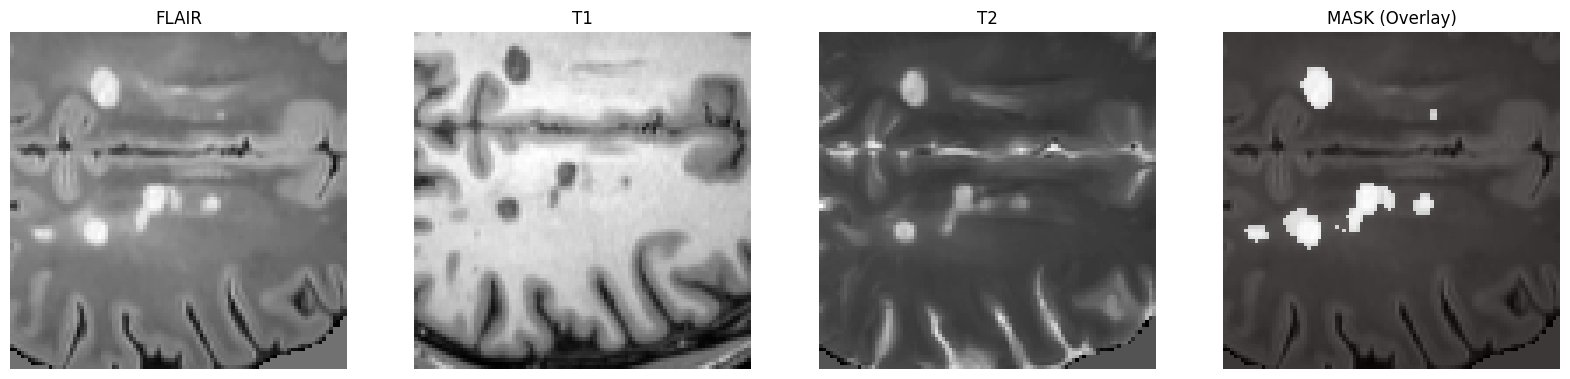

In [12]:
import matplotlib.pyplot as plt

def visualize_loader_sample(loader):
    batch = next(iter(loader))
    # image: [B, C, H, W, D], label: [B, 1, H, W, D]
    img = batch["image"][0].cpu().numpy()
    lbl = batch["label"][0, 0].cpu().numpy()

    slice_idx = img.shape[2] // 2
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    titles = ["FLAIR", "T1", "T2", "MASK (Overlay)"]

    for i in range(3):
        axes[i].imshow(img[i, :, :, slice_idx], cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')

    # Overlay
    axes[3].imshow(img[0, :, :, slice_idx], cmap='gray')
    axes[3].imshow(lbl[:, :, slice_idx], cmap='hot', alpha=0.5)
    axes[3].set_title(titles[3])
    axes[3].axis('off')

    plt.show()

print("Verifying sample directly from train_loader:")
visualize_loader_sample(train_loader)